# Análisis Exploratorio y de Procesamiento de Lenguaje Natural (PLN)
## Comunidad: GDG Hermosillo

Este notebook presenta el análisis completo del historial de interacciones de la comunidad **GDG Hermosillo** en WhatsApp. El objetivo es desglosar de manera modular el comportamiento de los miembros, los patrones temporales de participación, el ecosistema de recursos compartidos y las tendencias temáticas mediante técnicas de ingeniería de características y PLN.

###  Estructura del Análisis:
1. **Configuración inicial:** mportación de librerías, configuración de estilos y carga de módulos personalizados (`features.py` y `plots.py`) .
2. **Carga de Datos:** Ingesta y limpieza inicial del dataset anonimizado.
3. **Análisis Exploratorio de Datos:** 
    * **Dinámica y Comportamiento de los Miembros:** Identificación de usuarios más activos, volumen de mensajes y segmentación entre perfiles elaborados y respuestas cortas o reacciones.
    * **Dinámica Temporal:** Identificación de los días y horas de mayor engagement en la comunidad.
    * **Análisis Semántico (PLN):** Extracción de adjetivos clave con `spaCy` y generación de nubes de palabras.
    * **Ecosistema de Enlaces:** Mapeo de las plataformas técnicas más compartidas (YouTube, GitHub, LinkedIn).
4. **Conclusión Final:**

## 1. Configuración del Entorno

In [ ]:
#%cd ..
#!pip install -r requirements.txt

In [ ]:
# Import standard libraries and project utilities
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import pandas as pd

# Add the project root directory to Python's path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import project modules 
from modules.config import PROCESSED_DATA_DIR, FIGURES_DIR, RAW_DATA_DIR
from modules.dataset import anonymize_chat, clean_chat_text
import modules.features as fts
import modules.plots as plts
from IPython.display import display, Markdown


## 2. Carga de Datos

In [2]:
df_anonymized = anonymize_chat(
    input_path=RAW_DATA_DIR / "chat_whatsapp.txt", 
    output_path=PROCESSED_DATA_DIR / "chat_anonymized.txt"
)

2026-09-24 12:43:18.502 | INFO     | modules.dataset:anonymize_chat:144 - Leyendo archivo crudo: chat_whatsapp.txt
2026-09-24 12:43:25.932 | SUCCESS  | modules.dataset:anonymize_chat:197 - ¡Chat anonimizado con éxito! Guardado en: chat_whatsapp.txt
2026-09-24 12:43:25.932 | INFO     | modules.dataset:anonymize_chat:198 - Mapeo de usuarios generado con éxito.


## 3. Análisis Exploratorio de Datos

### 3.1 Dinámica y Comportamiento de los Miembros del Grupo

#### ¿Cuál es el usuario que más mensajes envía?

2026-09-24 12:43:27.430 | INFO     | modules.features:get_top_active_members:29 - Calculando miembros más activos...


| sender         |   count |
|:---------------|--------:|
| Miembro_GDG_5  |     150 |
| Miembro_GDG_8  |      87 |
| Miembro_GDG_3  |      82 |
| Miembro_GDG_14 |      30 |
| Miembro_GDG_19 |      17 |
| Miembro_GDG_63 |      16 |
| Miembro_GDG_21 |      14 |
| Miembro_GDG_26 |      14 |
| Miembro_GDG_7  |      13 |
| Miembro_GDG_18 |      13 |

2026-09-24 12:43:27.638 | SUCCESS  | modules.plots:plot_top_active_members:49 - Gráfico de top usuarios guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\miembros_activos.png


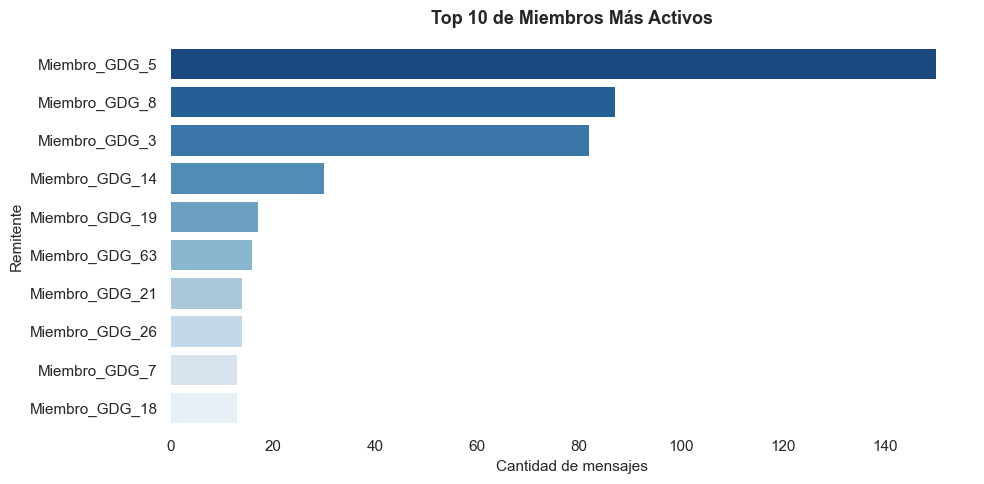

In [3]:
# Get top 10 active members
top_users = fts.get_top_active_members(df_anonymized, top_n=10)
display(Markdown(top_users.reset_index().to_markdown(index=False)))

# Generate and display the graph
fig1 = plts.plot_top_active_members(top_users, top_n=10, output_path=FIGURES_DIR / "miembros_activos.png")
plt.show()

#### ¿Cuál es la frecuencia promedio de palabras por mensaje de texto de cada usuario?

2026-09-24 12:43:43.716 | INFO     | modules.features:get_average_user_word_count:37 - Calculando promedio de palabras por usuario...


| sender         |   word_count |
|:---------------|-------------:|
| Miembro_GDG_50 |     133      |
| Miembro_GDG_51 |     113      |
| Miembro_GDG_5  |      46.52   |
| Miembro_GDG_35 |      33.6667 |
| Miembro_GDG_4  |      33.5714 |
| Miembro_GDG_6  |      29.8333 |
| Miembro_GDG_57 |      26.6667 |
| Miembro_GDG_10 |      26      |
| Miembro_GDG_49 |      26      |
| Miembro_GDG_21 |      25.9286 |

2026-09-24 12:43:43.918 | SUCCESS  | modules.plots:plot_top_average_word_count:82 - Gráfico de promedio de palabras guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\promedio_palabras.png


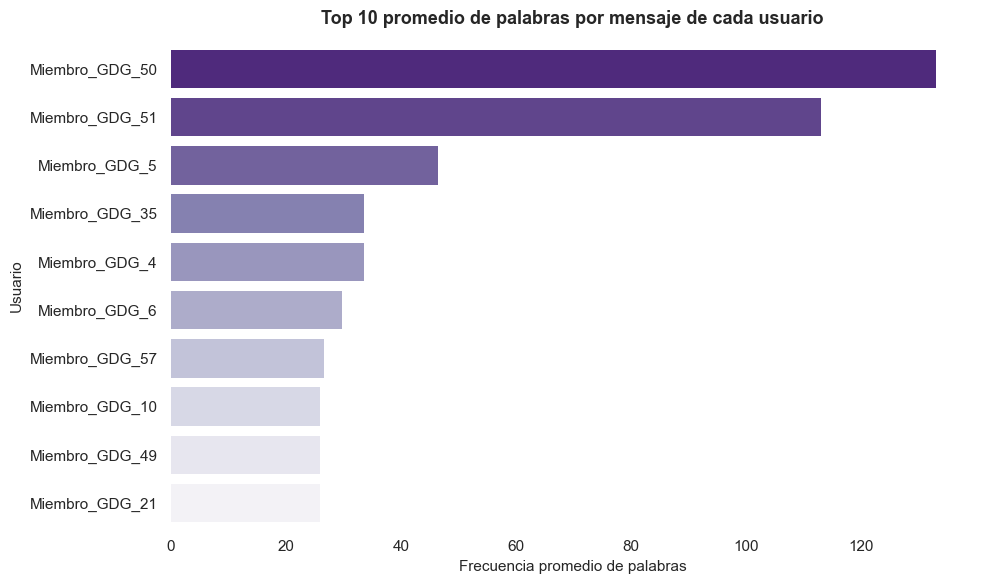

In [4]:
# Get average word count 
df_word_count = fts.get_average_user_word_count(df_anonymized, top_n=10)
display(Markdown(df_word_count.to_markdown(index=False)))

# Generate and display the graph
fig2 = plts.plot_top_average_word_count(df_word_count, top_n=10, output_path=FIGURES_DIR / "promedio_palabras.png")
plt.show()

#### ¿Quiénes escriben mensajes más largos o elaborados vs. quiénes mandan mensajes cortos/reacciones?

2026-09-24 12:43:49.842 | INFO     | modules.features:get_user_statistics:61 - Calculando estadísticas de mensajes por usuario...
Top 10 usuarios por actividad:


| sender         |   total_messages |   total_characters |   avg_message_size |
|:---------------|-----------------:|-------------------:|-------------------:|
| Miembro_GDG_5  |              150 |              51766 |           345.107  |
| Miembro_GDG_8  |               87 |               6438 |            74      |
| Miembro_GDG_3  |               82 |               6862 |            83.6829 |
| Miembro_GDG_14 |               30 |               2156 |            71.8667 |
| Miembro_GDG_19 |               17 |                507 |            29.8235 |
| Miembro_GDG_63 |               16 |                358 |            22.375  |
| Miembro_GDG_26 |               14 |               1625 |           116.071  |
| Miembro_GDG_21 |               14 |               2538 |           181.286  |
| Miembro_GDG_44 |               13 |                630 |            48.4615 |
| Miembro_GDG_37 |               13 |               1225 |            94.2308 |

2026-09-24 12:43:50.054 | SUCCESS  | modules.plots:plot_boxplot_message_size:130 - Boxplot de tamaño de mensajes guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\boxplot_tamano_mensajes.png


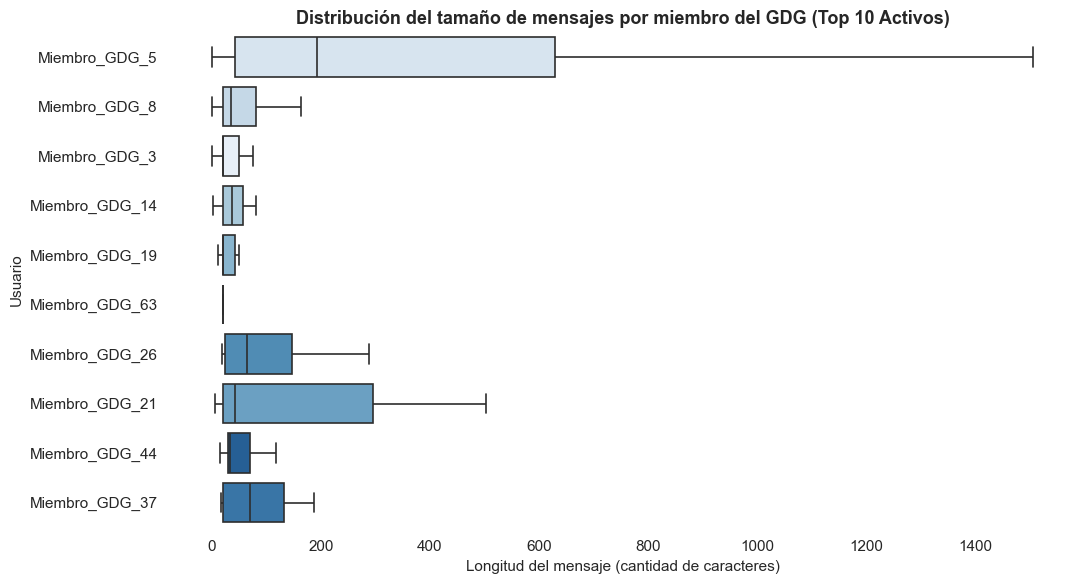

In [5]:
# Get table with summary statistics by user.
df_user_stats =fts.get_user_statistics(df_anonymized)

# Print reference table
print("Top 10 usuarios por actividad:")
display(Markdown(df_user_stats.head(10).to_markdown(index=False)))

# Generate and display the graph
fig = plts.plot_boxplot_message_size(df_anonymized, df_user_stats, top_n=10, output_path=FIGURES_DIR / "boxplot_tamano_mensajes.png")
plt.show()

2026-09-24 12:43:54.807 | INFO     | modules.features:get_users_short_messages:91 - Calculando usuarios con mensajes más cortos...
Top 10 miembros con mensajes más cortos en promedio:


| sender         |   avg_message_size |   total_messages |
|:---------------|-------------------:|-----------------:|
| Miembro_GDG_56 |                3   |                1 |
| Miembro_GDG_62 |                5   |                1 |
| Miembro_GDG_64 |                6   |                1 |
| Miembro_GDG_20 |                8   |                1 |
| Miembro_GDG_34 |               15.4 |                5 |

2026-09-24 12:43:54.952 | SUCCESS  | modules.plots:plot_short_users_scatter:178 - Gráfico de mensajes cortos guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\miembros_mensajes_cortos.png


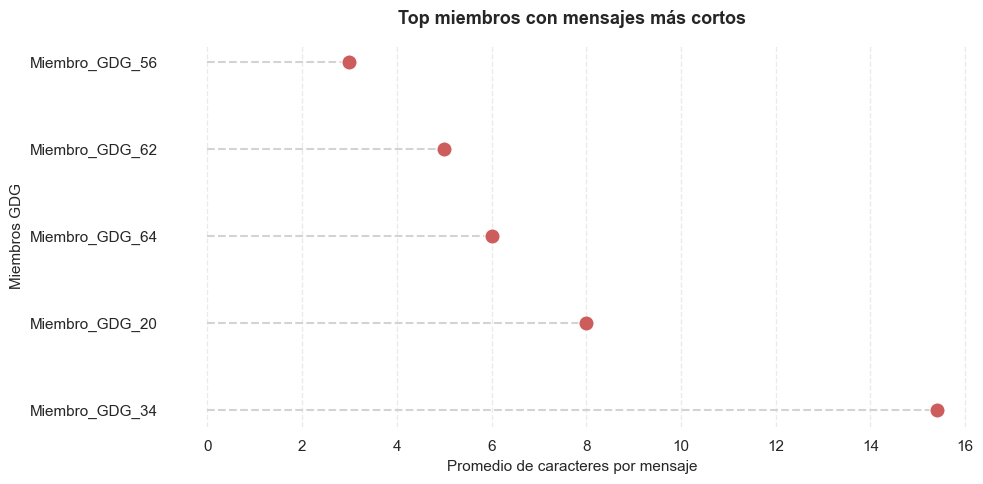

In [6]:
# Get the subset of users with the shortest messages
df_short_messages = fts.get_users_short_messages(df_anonymized, top_n=5)
        
# Print reference table
print("Top 10 miembros con mensajes más cortos en promedio:")
display(Markdown(df_short_messages[['sender', 'avg_message_size', 'total_messages']].to_markdown(index=False)))

# Generate and display the graph
fig = plts.plot_short_users_scatter(df_short_messages, output_path=FIGURES_DIR / "miembros_mensajes_cortos.png")
plt.show()


>  **Conclusión: Dinámica y comportamiento de los miembros del grupo GDG**
> 
> El análisis de participación revela una comunidad activa con perfiles de interacción muy bien diferenciados:
> 
> *  **Liderazgo en volumen:** **`Miembro_GDG_5`** encabeza la participación con **150 mensajes**, seguido por **`Miembro_GDG_8`** (87 msgs) y **`Miembro_GDG_3`** (82 msgs), conformando el núcleo principal que sostiene la conversación diaria.
> *  **Estilos de escritura (Elaboración vs. Brevedad):** 
>    * **Participación masiva y constante:** `Miembro_GDG_5` combina una alta frecuencia de mensajes con una gran cantidad de caracteres aportados.
>    * **Intervenciones de alta extensión:** Casos como **`Miembro_GDG_26`** muestran que, a pesar de enviar menos mensajes en total, priorizan aportaciones mucho más desarrolladas y largas por cada intervención.
>    * **Respuestas rápidas:** En el extremo opuesto, perfiles como **`Miembro_GDG_63`** y **`Miembro_GDG_19`** se caracterizan por mensajes cortos y dinámicos.

### 3.2 Distribución Temporal de Mensajes (Por Día y Hora)

#### ¿Qué días de la semana se mandan más mensajes y cuales menos? ¿Hay un patron semanal? ¿Y por hora del día?

2026-09-24 12:44:15.326 | INFO     | modules.features:get_messages_by_day:173 - Procesando mensajes por día de la semana...
2026-09-24 12:44:15.520 | SUCCESS  | modules.plots:plot_messages_by_day:211 - Gráfico por día guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\mensajes_por_dia.png


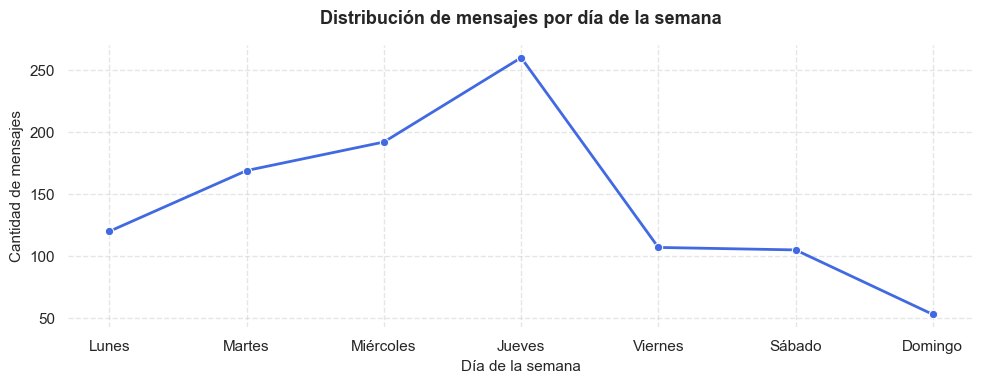

2026-09-24 12:44:15.584 | INFO     | modules.features:get_messages_by_hour:180 - Procesando mensajes por hora del día...
2026-09-24 12:44:15.845 | SUCCESS  | modules.plots:plot_messages_by_hour:241 - Gráfico por hora guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\mensajes_por_hora.png


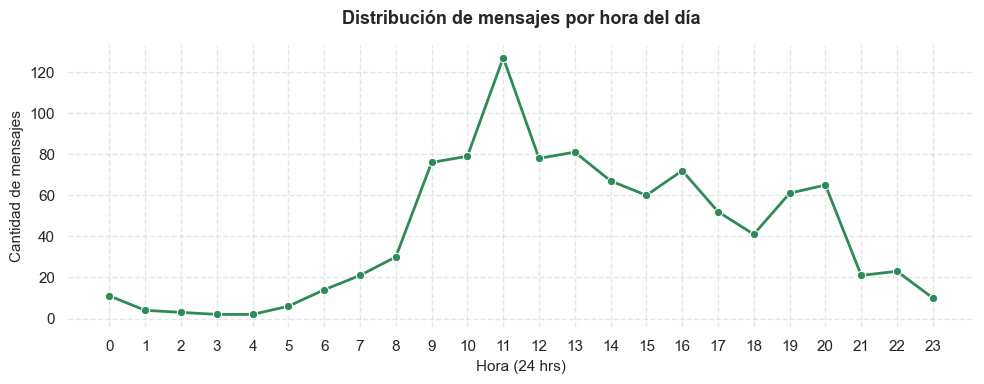

In [7]:
# Chart by day of the week
df_days = fts.get_messages_by_day(df_anonymized)
fig = plts.plot_messages_by_day(df_days, output_path=FIGURES_DIR / "mensajes_por_dia.png")
plt.show()

# Hourly chart
df_hours = fts.get_messages_by_hour(df_anonymized)
fig3 = plts.plot_messages_by_hour(df_hours, output_path=FIGURES_DIR / "mensajes_por_hora.png")
plt.show()

2026-09-24 12:44:37.852 | INFO     | modules.features:get_heatmap_data:187 - Generando tabla pivote para el mapa de calor...
2026-09-24 12:44:38.186 | SUCCESS  | modules.plots:plot_messages_heatmap:270 - Mapa de calor guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\heatmap_mensajes.png


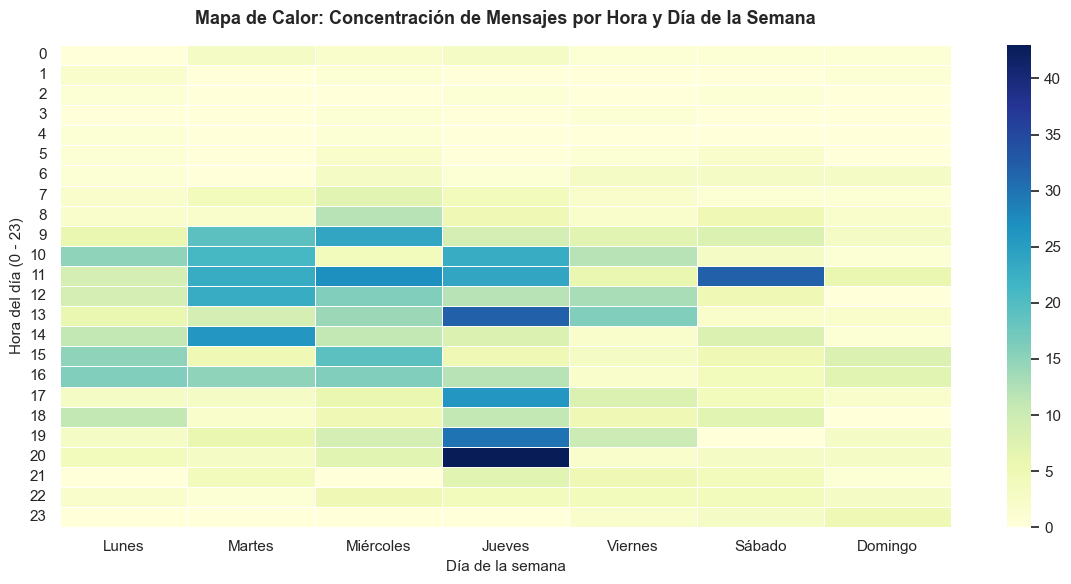

In [8]:
# Get heatmap data hours/days
df_heatmap_data = fts.get_heatmap_data(df_anonymized)

# Generate and display the heatmap
fig_heatmap = plts.plot_messages_heatmap(df_heatmap_data, FIGURES_DIR / "heatmap_mensajes.png")
plt.show()

>  **Conclusión: Patrones temporales de actividad**
> 
> La distribución temporal muestra una dinámica semanal muy definida, donde la participación se concentra fuertemente en días específicos y en franjas horarias clave:
> 
> *  **Días de mayor actividad:** Los **jueves** lideran la participación, seguidos de cerca por el **sábado** y el **miércoles**, mientras que el **domingo** registra la menor afluencia, marcando un claro contraste de descanso en la comunidad.
> *  **Hora pico general:** El flujo constante durante las mañanas posiciona a las **11:00 a.m.** como el horario con mayor volumen global de mensajes.
> *  **Pico máximo absoluto:** Al cruzar las variables en el mapa de calor, se identifica que el momento de mayor intensidad en toda la semana ocurre específicamente el **jueves a las 8:00 p.m.**

### 3.3 Métricas de Texto

#### ¿Qué palabras son las más usadas por cada usuario? ¿Y en general? ¿Qué palabras son las más usadas en el grupo que no sean *stop words*? 

In [9]:
# Cleaning the text
processed_text = clean_chat_text(df_anonymized)

2026-09-24 10:47:57.471 | SUCCESS  | modules.plots:plot_wordcloud:243 - Nube de palabras guardada en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\wordcloud.png


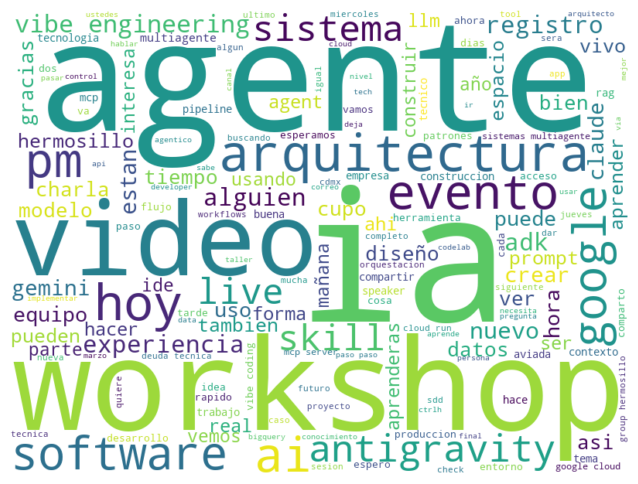

In [ ]:
# Generate and display the word cloud using the cleaned text
fig_wc = plts.plot_wordcloud(processed_text, output_path=FIGURES_DIR / "wordcloud.png")
plt.show()

#### ¿Cuáles son los adjetivos más usados?

2026-09-24 12:44:59.791 | INFO     | modules.features:get_adjective_frequency:208 - Extrayendo adjetivos con spaCy desde el texto procesado...
2026-09-24 12:45:00.770 | SUCCESS  | modules.plots:plot_top_adjectives:332 - Gráfico de adjetivos guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\top_adjetivos.png


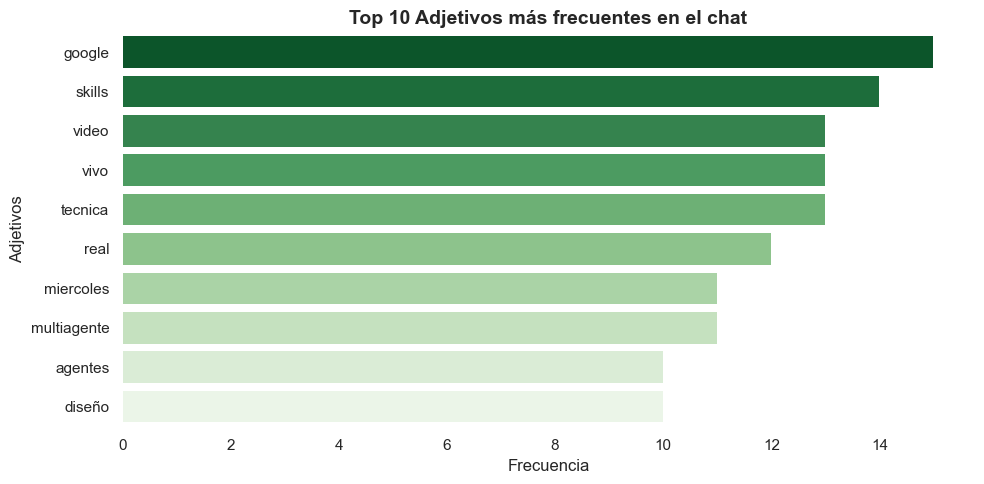

In [10]:
# Get adjective frequencies using the cleaned text
df_adj = fts.get_adjective_frequency(processed_text)

# Graph the top 10 adjectives
fig_adj = plts.plot_top_adjectives(df_adj, top_n=10, output_path=FIGURES_DIR / "top_adjetivos.png")
plt.show()

#### ¿Cuáles son los emojis más usados?

In [11]:
# Get top 10 processed emojis
top_emojis_df = fts.get_emoji_frequency(df_anonymized, top_n=10)

# Display the styled table
print("Top 10 emojis más usados en el chat:")
display(plts.get_emoji_table(top_emojis_df))

2026-09-24 12:45:03.894 | INFO     | modules.features:get_emoji_frequency:235 - Extrayendo y contando emojis del chat...
Top 10 emojis más usados en el chat:


Emoji,Frecuencia
✅,41
🚀,24
🔹,20
👉,12
📍,8
🤖,8
🤘,7
📅,7
🤣,5
✨,5


#### ¿Qué plataformas o recursos se comparten más en la comunidad? (¿GitHub, YouTube, Meetup, Medium, documentación oficial?).


2026-09-24 12:45:06.317 | INFO     | modules.features:get_top_shared_domains:280 - Extrayendo y procesando enlaces del chat...


,message,count
0,youtube.com,33
1,linkedin.com,24
2,devhack.co,19
3,github.com,11
4,luma.com,10
5,meetup.com,6
6,instagram.com,5
7,jggomezt.medium.com,5
8,medium.com,5
9,gdg.community.dev,4


2026-09-24 12:45:06.496 | SUCCESS  | modules.plots:plot_top_domains:390 - Gráfico de dominios guardado en C:\Users\patyq\OneDrive - Universidad de Sonora\MDC\IngCaracteristicas\whatsapp-chat-analytics\reports\figures\dominios_compartidos.png


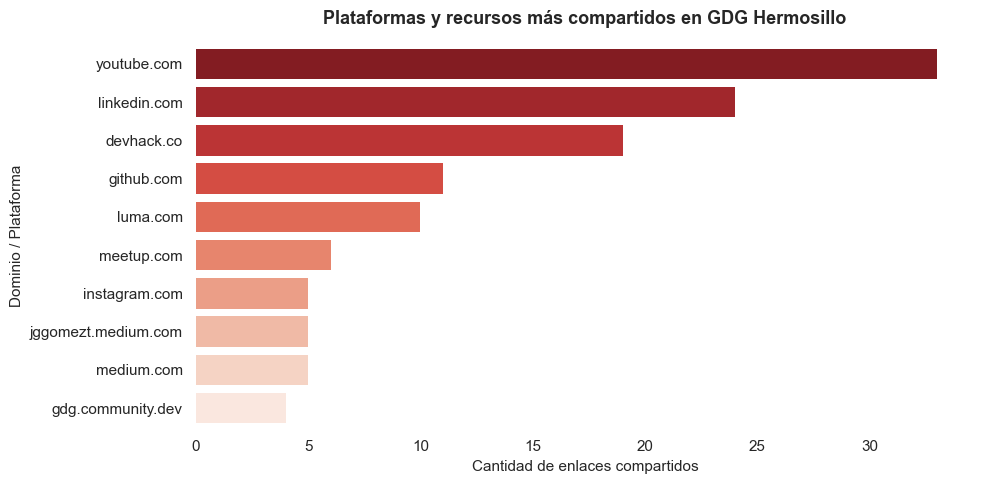

In [12]:
# Get top domains
df_dominios = fts.get_top_shared_domains(df_anonymized, top_n=10)
display(df_dominios)

# Generate and display the graph
fig = plts.plot_top_domains(df_dominios, community_name="GDG Hermosillo", output_path=FIGURES_DIR / "dominios_compartidos.png")
plt.show()

>  **Conclusión: Análisis de métricas de texto y contenido**
> 
> El análisis semántico y de lenguaje del chat refleja una fuerte orientación hacia temas técnicos, eventos prácticos y el desarrollo tecnológico:
> 
> *  **Temas centrales (Nube de palabras):** Términos como **"workshop"**, **"evento"**, **"agente"**, **"arquitectura"** y referencias a herramientas como **"gemini"** dominan las conversaciones, evidenciando un enfoque constante en inteligencia artificial y arquitectura de software.
> *  **Adjetivos más frecuentes:** Palabras como **"vivo"**, **"video"**, **"real"** y **"técnica"** resaltan la naturaleza dinámica de la comunidad, centrada en transmisiones en vivo, demostraciones prácticas y casos de uso del mundo real.
> *  **Plataformas y recursos compartidos:** Predominan los enlaces a recursos audiovisuales y profesionales como **YouTube** y **LinkedIn**, respaldados por plataformas de desarrollo y difusión técnica como **Devhack** y **GitHub**, lo que subraya el intercambio activo de tutoriales, código y eventos de la comunidad.

## 4. Conclusión Final


> El análisis integral del chat de **GDG Hermosillo** revela una comunidad tecnológica vibrante, altamente colaborativa y con dinámicas de participación muy estructuradas:
> 
> *  **Dinámica y participación:** La conversación se sostiene gracias a un núcleo activo de usuarios liderado por perfiles constantes (como `Miembro_GDG_5`), combinando intervenciones masivas con aportaciones técnicas profundas y detalladas por parte de miembros clave (como `Miembro_GDG_26`).
> *  **Patrones temporales:** La actividad muestra un ritmo semanal muy marcado con picos de mayor afluencia los **jueves** (destacando el momento más intenso de la semana a las 8:00 p.m.) y los **sábados**, con un flujo constante durante las mañanas que alcanza su punto general a las 11:00 a.m.
> *  **Enfoque temático y contenido:** El lenguaje y los adjetivos más frecuentes reflejan un claro interés práctico centrado en **Inteligencia Artificial, agentes, arquitectura de software y workshops** (con menciones destacadas a herramientas como Gemini y Claude).
> *  **Intercambio de recursos:** El ecosistema se alimenta fuertemente de contenido externo profesional y educativo, predominando el uso de plataformas de video y código como **YouTube, LinkedIn y GitHub**.
> 
> En conjunto, el grupo funciona como un canal de aprendizaje continuo y difusión técnica sumamente activo, donde la teoría y la práctica del desarrollo de software se traducen en interacción constante.